In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import itertools

from tensorflow.keras import layers, models
from PIL import Image, ImageDraw

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
IMG_SIZE = 64

N_TRAIN = 10000
N_TEST = 2000

VECTOR_EPOCHS = 50
RASTER_EPOCHS = 100

BATCH_SIZE = 32

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
MAX_LINES = 5
MIN_LINES = 1
CONFIDENCE_THRESHOLD = 0.9

# Each predicted line is:
# x1, y1, x2, y2, confidence
VALUES_PER_LINE = 5

# These weights control the synthetic data distribution only.
# The model is not manually given these weights.
ANGLE_WEIGHT_HORIZONTAL = 60  # 0 degrees
ANGLE_WEIGHT_VERTICAL = 60    # 90 degrees
ANGLE_WEIGHT_45 = 25          # 45, 135
ANGLE_WEIGHT_60 = 15          # 60, 120
ANGLE_WEIGHT_30 = 10          # 30, 150
ANGLE_WEIGHT_5 = 7            # other multiples of 5 degrees
ANGLE_WEIGHT_OTHER = 3        # all other integer-degree angles

LINE_WIDTH = 1


def build_angle_groups():
    """
    Build disjoint angle groups from 0 to 179 degrees.

    180 degrees is excluded because a line at 180 degrees is the same direction as 0 degrees.
    """
    all_angles = set(range(0, 180))

    horizontal = {0}
    vertical = {90}

    angle_45 = {
        angle for angle in all_angles
        if angle % 45 == 0
        and angle not in horizontal
        and angle not in vertical
    }

    angle_60 = {
        angle for angle in all_angles
        if angle % 60 == 0
        and angle not in horizontal
        and angle not in vertical
        and angle not in angle_45
    }

    angle_30 = {
        angle for angle in all_angles
        if angle % 30 == 0
        and angle not in horizontal
        and angle not in vertical
        and angle not in angle_45
        and angle not in angle_60
    }

    angle_5 = {
        angle for angle in all_angles
        if angle % 5 == 0
        and angle not in horizontal
        and angle not in vertical
        and angle not in angle_45
        and angle not in angle_60
        and angle not in angle_30
    }

    used_angles = horizontal | vertical | angle_45 | angle_60 | angle_30 | angle_5
    angle_other = all_angles - used_angles

    return {
        "horizontal": sorted(horizontal),
        "vertical": sorted(vertical),
        "45": sorted(angle_45),
        "60": sorted(angle_60),
        "30": sorted(angle_30),
        "5": sorted(angle_5),
        "other": sorted(angle_other),
    }


ANGLE_GROUPS = build_angle_groups()


def choose_weighted_angle():
    """
    Choose one integer-degree angle between 0 and 179.

    The weighting is only used to create the synthetic images.
    The model learns angle tendencies from the examples, not from these weights directly.
    """
    group_names = ["horizontal", "vertical", "45", "60", "30", "5", "other"]

    group_weights = np.array([
        ANGLE_WEIGHT_HORIZONTAL,
        ANGLE_WEIGHT_VERTICAL,
        ANGLE_WEIGHT_45,
        ANGLE_WEIGHT_60,
        ANGLE_WEIGHT_30,
        ANGLE_WEIGHT_5,
        ANGLE_WEIGHT_OTHER
    ], dtype="float32")

    if np.sum(group_weights) <= 0:
        raise ValueError("At least one angle weight must be greater than 0.")

    group_probabilities = group_weights / np.sum(group_weights)

    selected_group = np.random.choice(group_names, p=group_probabilities)
    selected_angle = np.random.choice(ANGLE_GROUPS[selected_group])

    return int(selected_angle)


def create_line_image(img_size=64, min_length=12, min_lines=1, max_lines=5):
    """
    Create one image containing between min_lines and max_lines random black lines.

    The image generator restricts line angles to integer-degree angles.
    The label stores endpoints only:

        [x1, y1, x2, y2, confidence]

    The final prediction decoder later snaps predicted endpoint angles to the nearest 1 degree.
    """

    def random_line():
        while True:
            angle_degrees = choose_weighted_angle()
            angle_radians = np.deg2rad(angle_degrees)

            cos_a = np.cos(angle_radians)
            sin_a = np.sin(angle_radians)

            # Maximum possible full line length that can fit in the image at this angle
            max_length_x = np.inf if abs(cos_a) < 1e-8 else (img_size - 1) / abs(cos_a)
            max_length_y = np.inf if abs(sin_a) < 1e-8 else (img_size - 1) / abs(sin_a)
            max_possible_length = min(max_length_x, max_length_y)

            if max_possible_length < min_length:
                continue

            line_length = np.random.uniform(min_length, max_possible_length)

            dx = cos_a * line_length / 2
            dy = sin_a * line_length / 2

            # Choose a centre point that keeps both endpoints inside the image
            cx_min = abs(dx)
            cx_max = (img_size - 1) - abs(dx)
            cy_min = abs(dy)
            cy_max = (img_size - 1) - abs(dy)

            if cx_min > cx_max or cy_min > cy_max:
                continue

            cx = np.random.uniform(cx_min, cx_max)
            cy = np.random.uniform(cy_min, cy_max)

            x1 = int(round(cx - dx))
            y1 = int(round(cy - dy))
            x2 = int(round(cx + dx))
            y2 = int(round(cy + dy))

            # Safety check after rounding
            if not (0 <= x1 < img_size and 0 <= y1 < img_size):
                continue
            if not (0 <= x2 < img_size and 0 <= y2 < img_size):
                continue

            actual_length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

            if actual_length >= min_length:
                return x1, y1, x2, y2, angle_degrees

    number_of_lines = np.random.randint(min_lines, max_lines + 1)

    lines = [random_line() for _ in range(number_of_lines)]

    # Sort line slots by centre point so labels are more consistent for training
    lines = sorted(
        lines,
        key=lambda line: (
            (line[0] + line[2]) / 2,
            (line[1] + line[3]) / 2
        )
    )

    image = Image.new("L", (img_size, img_size), color=255)
    draw = ImageDraw.Draw(image)

    label_values = []

    for line in lines:
        x1, y1, x2, y2, angle_degrees = line

        draw.line((x1, y1, x2, y2), fill=0, width=LINE_WIDTH)

        label_values.extend([
            x1 / (img_size - 1),
            y1 / (img_size - 1),
            x2 / (img_size - 1),
            y2 / (img_size - 1),
            1.0
        ])

    # Fill unused line slots with zeros
    while len(label_values) < max_lines * VALUES_PER_LINE:
        label_values.extend([0.0, 0.0, 0.0, 0.0, 0.0])

    image_array = np.array(image).astype("float32") / 255.0
    image_array = np.expand_dims(image_array, axis=-1)

    label = np.array(label_values, dtype="float32")

    return image_array, label


def create_dataset(n_samples, img_size=64):
    images = []
    labels = []

    for _ in range(n_samples):
        image, label = create_line_image(
            img_size=img_size,
            min_lines=MIN_LINES,
            max_lines=MAX_LINES
        )

        images.append(image)
        labels.append(label)

    return np.array(images), np.array(labels)


In [4]:
X_train, y_train = create_dataset(N_TRAIN, IMG_SIZE)
X_test, y_test = create_dataset(N_TEST, IMG_SIZE)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (10000, 64, 64, 1)
y_train: (10000, 25)
X_test: (2000, 64, 64, 1)
y_test: (2000, 25)


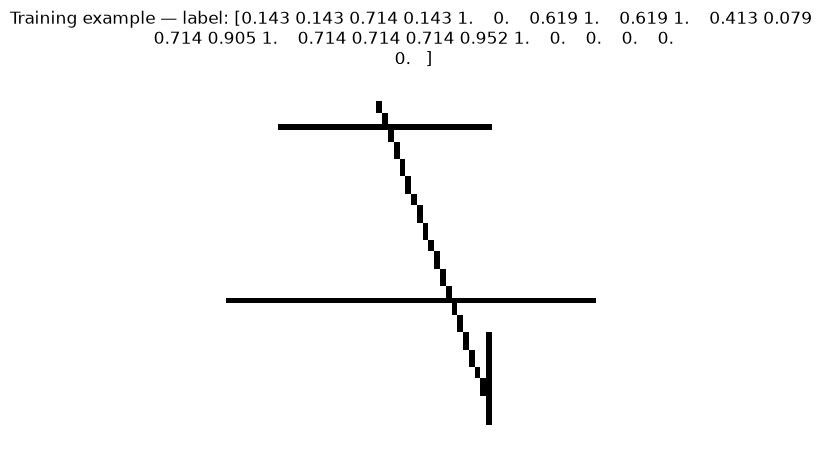

In [5]:
index = 0

plt.imshow(X_train[index].squeeze(), cmap="gray", vmin=0, vmax=1)
plt.title(f"Training example — label: {np.round(y_train[index], 3)}")
plt.axis("off")
plt.show()

In [6]:
def build_vector_model():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1), name="raster_input")

    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.Flatten()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    # Output is [x1, y1, x2, y2, confidence] × MAX_LINES
    # Sigmoid keeps all values between 0 and 1.
    vector_output = layers.Dense(
        MAX_LINES * VALUES_PER_LINE,
        activation="sigmoid",
        name="vector_output"
    )(x)

    return models.Model(inputs=inputs, outputs=vector_output, name="vector_model")


vector_model = build_vector_model()
vector_model.summary()


Model: "vector_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ raster_input (InputLayer)            │ (None, 64, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vector_output (Dense)                │ (None, 25)                  │           3,225 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,373,785 (9.06 MB)

 Trainable params: 2,373,785 (9.06 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
LINE_PERMUTATIONS = tf.constant(
    list(itertools.permutations(range(MAX_LINES))),
    dtype=tf.int32
)


def permutation_invariant_line_loss(y_true, y_pred):
    """
    Loss for unordered endpoint-based line sets.

    Each line is:
        x1, y1, x2, y2, confidence

    Reversed endpoints are treated as the same line:
        x1,y1 -> x2,y2
        is equivalent to
        x2,y2 -> x1,y1

    Predicted line slots are also treated as unordered, so the model is not punished when it predicts
    the correct lines in a different slot order. This helps at intersections, where several lines may
    have similar centre points.
    """

    y_true = tf.reshape(y_true, (-1, MAX_LINES, VALUES_PER_LINE))
    y_pred = tf.reshape(y_pred, (-1, MAX_LINES, VALUES_PER_LINE))

    # Try every possible predicted-slot ordering.
    y_pred_permuted = tf.gather(y_pred, LINE_PERMUTATIONS, axis=1)

    true_coords = y_true[:, None, :, 0:4]
    pred_coords = y_pred_permuted[:, :, :, 0:4]

    true_conf = y_true[:, None, :, 4]
    pred_conf = y_pred_permuted[:, :, :, 4]

    # Endpoint order as predicted
    direct_loss = tf.reduce_mean(
        tf.square(true_coords - pred_coords),
        axis=-1
    )

    # Endpoint order reversed
    reversed_pred_coords = tf.stack([
        pred_coords[:, :, :, 2],
        pred_coords[:, :, :, 3],
        pred_coords[:, :, :, 0],
        pred_coords[:, :, :, 1]
    ], axis=-1)

    reversed_loss = tf.reduce_mean(
        tf.square(true_coords - reversed_pred_coords),
        axis=-1
    )

    coordinate_loss = tf.minimum(direct_loss, reversed_loss)

    # Only apply coordinate loss to real line slots
    coordinate_loss = coordinate_loss * true_conf

    real_line_count = tf.reduce_sum(true_conf, axis=-1) + 1e-8

    coordinate_loss = tf.reduce_sum(
        coordinate_loss,
        axis=-1
    ) / real_line_count

    # Confidence loss is applied to every slot, including padded empty slots
    confidence_loss = tf.keras.backend.binary_crossentropy(
        true_conf,
        pred_conf
    )

    confidence_loss = tf.reduce_mean(confidence_loss, axis=-1)

    total_loss = coordinate_loss + 1.0 * confidence_loss

    # Use the best line-slot assignment for each sample
    best_loss = tf.reduce_min(total_loss, axis=1)

    return tf.reduce_mean(best_loss)


In [8]:
vector_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=permutation_invariant_line_loss,
    metrics=["mae"]
)

# early stop if over-fitting

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_vector = vector_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=VECTOR_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.3517 - mae: 0.3989 - val_loss: 0.2045 - val_mae: 0.3904
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 0.2092 - mae: 0.3844 - val_loss: 0.1665 - val_mae: 0.3696
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.1700 - mae: 0.3750 - val_loss: 0.1683 - val_mae: 0.3659
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.1409 - mae: 0.3751 - val_loss: 0.1152 - val_mae: 0.3735
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.1144 - mae: 0.3763 - val_loss: 0.1503 - val_mae: 0.3766
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 0.1041 - mae: 0.3801 - val_loss: 0.1045 - val_mae: 0.3732
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.0933 - mae: 0.3713 - val_loss: 0.0812 - val_mae: 0.3708
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 0.0889 - mae: 0.3718 - val_loss: 0.0998 - val_mae: 0.3655
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1

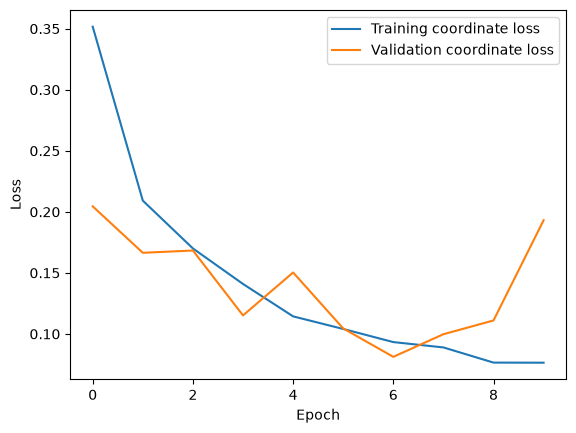

In [9]:
plt.plot(history_vector.history["loss"], label="Training coordinate loss")
plt.plot(history_vector.history["val_loss"], label="Validation coordinate loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [10]:
class DifferentiableLineRasteriser(layers.Layer):
    def __init__(self, img_size=64, sigma=0.018, **kwargs):
        super().__init__(**kwargs)
        self.img_size = img_size
        self.sigma = sigma

        xs = tf.linspace(0.0, 1.0, img_size)
        ys = tf.linspace(0.0, 1.0, img_size)

        grid_x, grid_y = tf.meshgrid(xs, ys)

        self.grid_x = tf.reshape(grid_x, (1, 1, img_size, img_size))
        self.grid_y = tf.reshape(grid_y, (1, 1, img_size, img_size))

    def call(self, vectors):
        vectors = tf.reshape(vectors, (-1, MAX_LINES, VALUES_PER_LINE))

        x1 = tf.reshape(vectors[:, :, 0], (-1, MAX_LINES, 1, 1))
        y1 = tf.reshape(vectors[:, :, 1], (-1, MAX_LINES, 1, 1))
        x2 = tf.reshape(vectors[:, :, 2], (-1, MAX_LINES, 1, 1))
        y2 = tf.reshape(vectors[:, :, 3], (-1, MAX_LINES, 1, 1))

        confidence = tf.reshape(vectors[:, :, 4], (-1, MAX_LINES, 1, 1))

        px = self.grid_x
        py = self.grid_y

        dx = x2 - x1
        dy = y2 - y1

        length_squared = dx * dx + dy * dy + 1e-8

        t = ((px - x1) * dx + (py - y1) * dy) / length_squared
        t = tf.clip_by_value(t, 0.0, 1.0)

        closest_x = x1 + t * dx
        closest_y = y1 + t * dy

        distance_squared = tf.square(px - closest_x) + tf.square(py - closest_y)

        line_darkness = tf.exp(
            -distance_squared / (2.0 * self.sigma * self.sigma)
        )

        line_darkness = line_darkness * confidence

        # Combine multiple black lines on a white background
        combined_darkness = 1.0 - tf.reduce_prod(
            1.0 - line_darkness,
            axis=1
        )

        raster = 1.0 - combined_darkness
        raster = tf.expand_dims(raster, axis=-1)

        return raster


removed the black weighting - test to see for improvment

In [24]:
def raster_loss(y_true, y_pred):
    loss = tf.square(y_true - y_pred)
    return tf.reduce_mean(loss)

In [25]:
raster_output = DifferentiableLineRasteriser(
    img_size=IMG_SIZE,
    sigma=0.010,
    name="raster_output"
)(vector_model.output)

training_model = models.Model(
    inputs=vector_model.input,
    outputs=[raster_output, vector_model.output],
    name="option_b_training_model"
)

training_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=[raster_loss, permutation_invariant_line_loss],
    loss_weights=[0.3, 1.0],
    metrics=[["mae"], ["mae"]]
)

early_stop_raster = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_raster = training_model.fit(
    X_train,
    [X_train, y_train],
    validation_data=(X_test, [X_test, y_test]),
    epochs=RASTER_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_raster],
    verbose=1
)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - loss: 0.0568 - raster_output_loss: 0.0509 - raster_output_mae: 0.0636 - vector_output_loss: 0.0415 - vector_output_mae: 0.3790 - val_loss: 0.0799 - val_raster_output_loss: 0.0454 - val_raster_output_mae: 0.0564 - val_vector_output_loss: 0.0662 - val_vector_output_mae: 0.3690
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 0.0554 - raster_output_loss: 0.0493 - raster_output_mae: 0.0612 - vector_output_loss: 0.0405 - vector_output_mae: 0.3761 - val_loss: 0.0801 - val_raster_output_loss: 0.0455 - val_raster_output_mae: 0.0565 - val_vector_output_loss: 0.0665 - val_vector_output_mae: 0.3679
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 0.0541 - raster_output_loss: 0.0491 - raster_output_mae: 0.0609 - vector_output_loss: 0.0393 - vector_output_mae: 0.3745 - val_loss: 0.0817 - val_raster_output_loss: 0.0454 - val_raster_output_mae: 0.0562 - val_vector_output_loss: 0.0682 - val_vector_output_mae: 0.3673
E

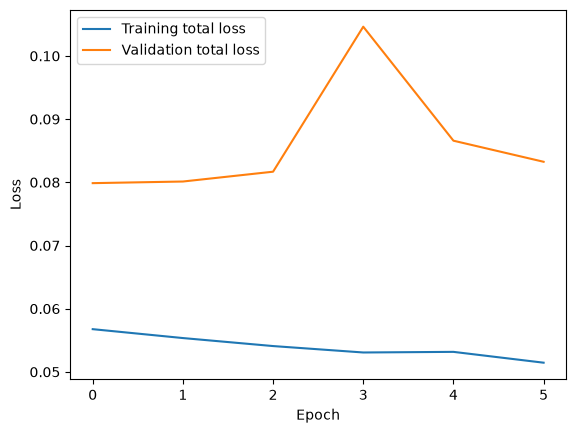

In [26]:
plt.plot(history_raster.history["loss"], label="Training total loss")
plt.plot(history_raster.history["val_loss"], label="Validation total loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Predicted snapped lines:
Line 1: (58, 3) to (4, 62), angle=133°, confidence=1.00


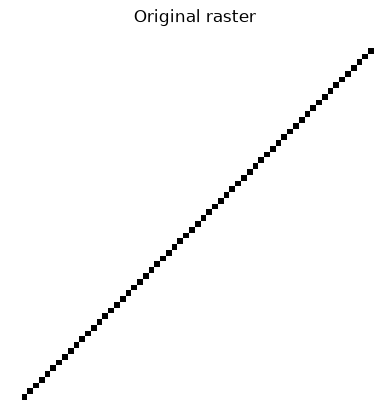

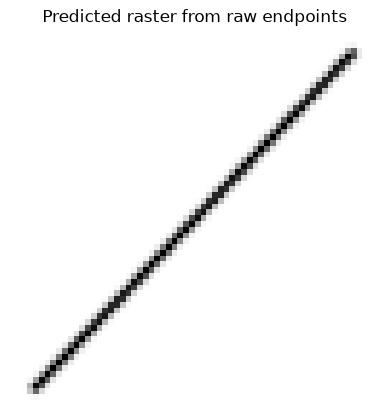

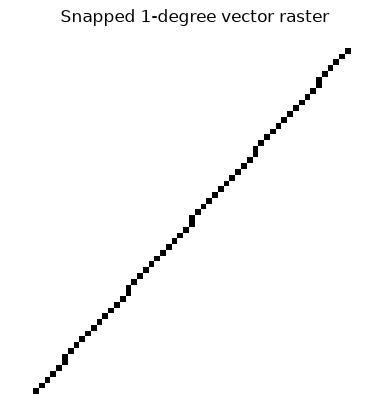

In [27]:
def snap_line_to_nearest_degree(x1, y1, x2, y2, img_size):
    """
    Take predicted endpoints and rebuild the line using the nearest 1-degree angle.

    The model itself predicts endpoints. The snap happens only during decoding/export.
    """

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2

    dx = x2 - x1
    dy = y2 - y1

    length = np.sqrt(dx ** 2 + dy ** 2)

    if length < 1e-8:
        return int(round(x1)), int(round(y1)), int(round(x2)), int(round(y2)), 0

    angle_degrees = np.degrees(np.arctan2(dy, dx))

    # Lines are undirected, so keep angle between 0 and 179 degrees
    angle_degrees = angle_degrees % 180

    # Snap to nearest 1 degree
    snapped_angle = int(round(angle_degrees)) % 180

    angle_radians = np.deg2rad(snapped_angle)

    new_dx = np.cos(angle_radians) * length / 2
    new_dy = np.sin(angle_radians) * length / 2

    new_x1 = int(round(cx - new_dx))
    new_y1 = int(round(cy - new_dy))
    new_x2 = int(round(cx + new_dx))
    new_y2 = int(round(cy + new_dy))

    new_x1 = int(np.clip(new_x1, 0, img_size - 1))
    new_y1 = int(np.clip(new_y1, 0, img_size - 1))
    new_x2 = int(np.clip(new_x2, 0, img_size - 1))
    new_y2 = int(np.clip(new_y2, 0, img_size - 1))

    return new_x1, new_y1, new_x2, new_y2, snapped_angle


def decode_endpoint_vector(vector, img_size=64, confidence_threshold=0.5, snap=True):
    """
    Decode endpoint-based model output.

    Expected vector shape:
        MAX_LINES * VALUES_PER_LINE

    Each line:
        x1, y1, x2, y2, confidence
    """

    vector = vector.reshape(MAX_LINES, VALUES_PER_LINE)

    decoded_lines = []

    for line in vector:
        x1, y1, x2, y2, confidence = line

        if confidence >= confidence_threshold:
            x1 = x1 * (img_size - 1)
            y1 = y1 * (img_size - 1)
            x2 = x2 * (img_size - 1)
            y2 = y2 * (img_size - 1)

            if snap:
                x1, y1, x2, y2, angle = snap_line_to_nearest_degree(
                    x1, y1, x2, y2, img_size
                )
            else:
                angle = np.degrees(np.arctan2(y2 - y1, x2 - x1)) % 180
                angle = int(round(angle)) % 180
                x1 = int(round(np.clip(x1, 0, img_size - 1)))
                y1 = int(round(np.clip(y1, 0, img_size - 1)))
                x2 = int(round(np.clip(x2, 0, img_size - 1)))
                y2 = int(round(np.clip(y2, 0, img_size - 1)))

            decoded_lines.append({
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "angle": angle,
                "confidence": float(confidence)
            })

    return decoded_lines


def rasterise_decoded_lines(decoded_lines, img_size=64):
    image = Image.new("L", (img_size, img_size), color=255)
    draw = ImageDraw.Draw(image)

    for line in decoded_lines:
        draw.line(
            (line["x1"], line["y1"], line["x2"], line["y2"]),
            fill=0,
            width=LINE_WIDTH
        )

    image_array = np.array(image).astype("float32") / 255.0
    return image_array


sample = X_test[0:1]

predicted_vector = vector_model.predict(sample, verbose=0)[0]
predicted_outputs = training_model.predict(sample, verbose=0)
predicted_raster = predicted_outputs[0][0]

raw_lines = decode_endpoint_vector(
    predicted_vector,
    img_size=IMG_SIZE,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    snap=False
)

snapped_lines = decode_endpoint_vector(
    predicted_vector,
    img_size=IMG_SIZE,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    snap=True
)

snapped_raster = rasterise_decoded_lines(snapped_lines, img_size=IMG_SIZE)

print("Predicted snapped lines:")

for i, line in enumerate(snapped_lines):
    print(
        f"Line {i + 1}: "
        f"({line['x1']}, {line['y1']}) to ({line['x2']}, {line['y2']}), "
        f"angle={line['angle']}°, "
        f"confidence={line['confidence']:.2f}"
    )

plt.imshow(sample.squeeze(), cmap="gray", interpolation="nearest")
plt.title("Original raster")
plt.axis("off")
plt.show()

plt.imshow(predicted_raster.squeeze(), cmap="gray", interpolation="nearest")
plt.title("Predicted raster from raw endpoints")
plt.axis("off")
plt.show()

plt.imshow(snapped_raster.squeeze(), cmap="gray", interpolation="nearest")
plt.title("Snapped 1-degree vector raster")
plt.axis("off")
plt.show()


Example 0
True lines:
  (62, 3) to (2, 63), angle≈135°, confidence=1.00
Predicted snapped lines:
  (58, 3) to (4, 62), angle=133°, confidence=1.00


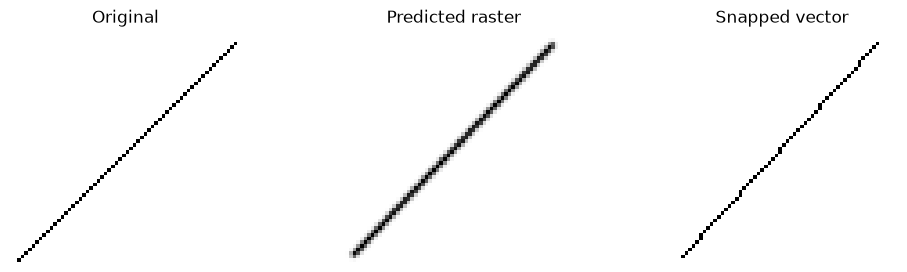

Example 1
True lines:
  (20, 0) to (20, 63), angle≈90°, confidence=1.00
  (59, 2) to (5, 56), angle≈135°, confidence=1.00
  (32, 50) to (45, 50), angle≈0°, confidence=1.00
Predicted snapped lines:
  (27, 15) to (20, 54), angle=100°, confidence=1.00
  (39, 42) to (14, 54), angle=154°, confidence=1.00
  (44, 11) to (13, 50), angle=129°, confidence=1.00


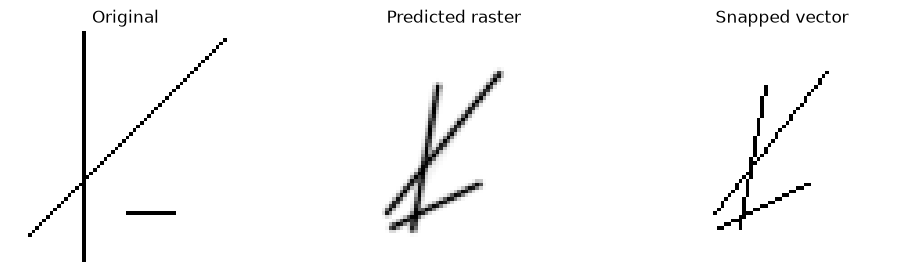

Example 2
True lines:
  (28, 4) to (58, 55), angle≈60°, confidence=1.00
Predicted snapped lines:
  (36, 5) to (51, 53), angle=72°, confidence=1.00


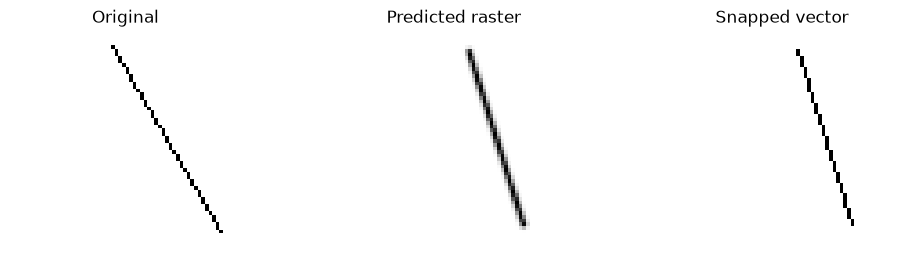

Example 3
True lines:
  (42, 16) to (42, 46), angle≈90°, confidence=1.00
  (62, 23) to (62, 47), angle≈90°, confidence=1.00
Predicted snapped lines:
  (62, 8) to (62, 60), angle=90°, confidence=1.00
  (42, 15) to (50, 49), angle=77°, confidence=1.00


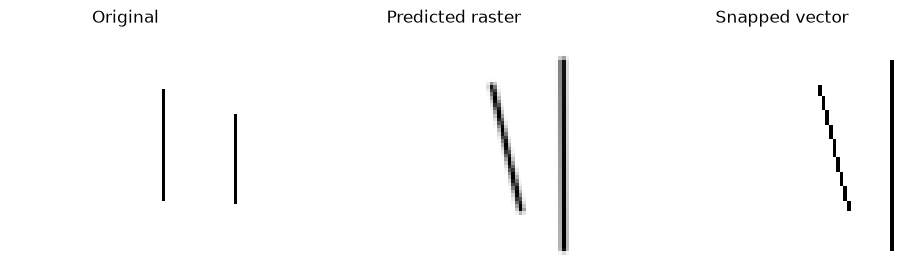

Example 4
True lines:
  (12, 3) to (10, 28), angle≈95°, confidence=1.00
  (4, 4) to (53, 4), angle≈0°, confidence=1.00
  (5, 61) to (54, 61), angle≈0°, confidence=1.00
  (8, 17) to (61, 17), angle≈0°, confidence=1.00
Predicted snapped lines:
  (19, 13) to (8, 27), angle=128°, confidence=1.00
  (17, 29) to (32, 37), angle=30°, confidence=1.00
  (45, 61) to (11, 62), angle=179°, confidence=1.00
  (8, 1) to (46, 8), angle=9°, confidence=1.00


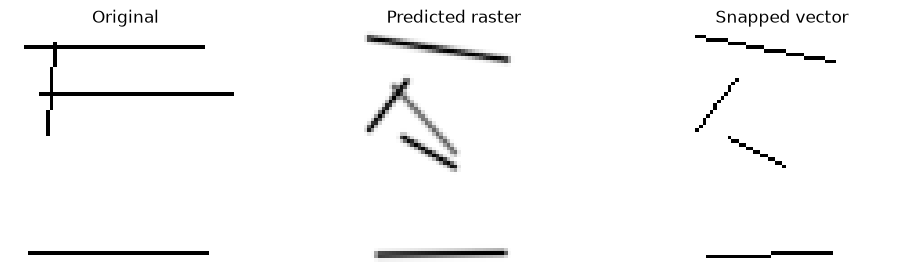

Example 5
True lines:
  (3, 46) to (22, 46), angle≈0°, confidence=1.00
  (17, 13) to (17, 33), angle≈90°, confidence=1.00
  (3, 1) to (34, 19), angle≈30°, confidence=1.00
  (10, 23) to (48, 23), angle≈0°, confidence=1.00
  (40, 12) to (40, 51), angle≈90°, confidence=1.00
Predicted snapped lines:
  (26, 18) to (15, 39), angle=116°, confidence=1.00
  (25, 11) to (32, 45), angle=77°, confidence=1.00
  (30, 23) to (32, 38), angle=83°, confidence=1.00
  (16, 37) to (39, 43), angle=14°, confidence=1.00
  (40, 20) to (12, 20), angle=179°, confidence=1.00


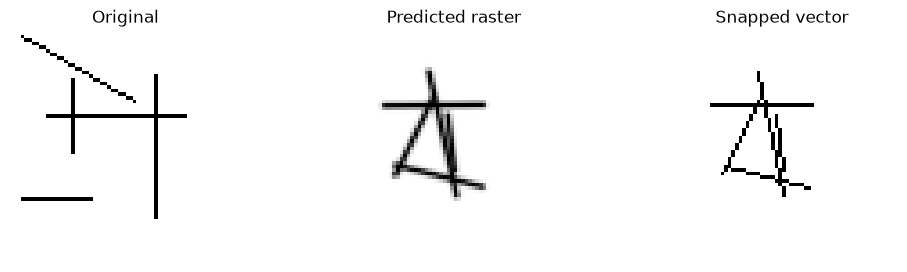

Example 6
True lines:
  (11, 46) to (51, 46), angle≈0°, confidence=1.00
  (54, 21) to (54, 54), angle≈90°, confidence=1.00
Predicted snapped lines:
  (53, 26) to (53, 49), angle=92°, confidence=1.00
  (19, 44) to (55, 50), angle=9°, confidence=1.00


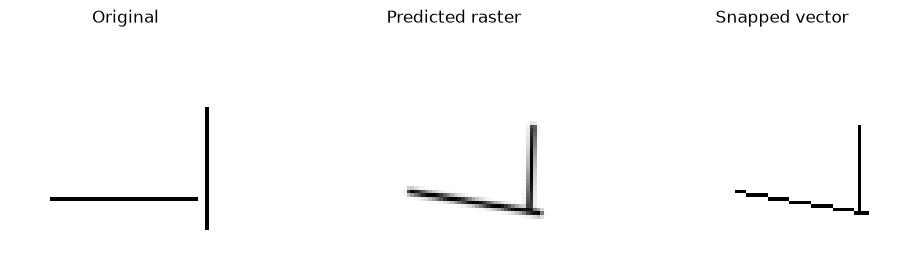

Example 7
True lines:
  (26, 28) to (26, 59), angle≈90°, confidence=1.00
  (11, 26) to (44, 59), angle≈45°, confidence=1.00
  (10, 45) to (62, 45), angle≈0°, confidence=1.00
  (44, 37) to (44, 56), angle≈90°, confidence=1.00
Predicted snapped lines:
  (19, 27) to (28, 53), angle=69°, confidence=1.00
  (35, 34) to (45, 51), angle=60°, confidence=1.00
  (17, 39) to (51, 52), angle=20°, confidence=1.00
  (39, 39) to (18, 45), angle=164°, confidence=1.00


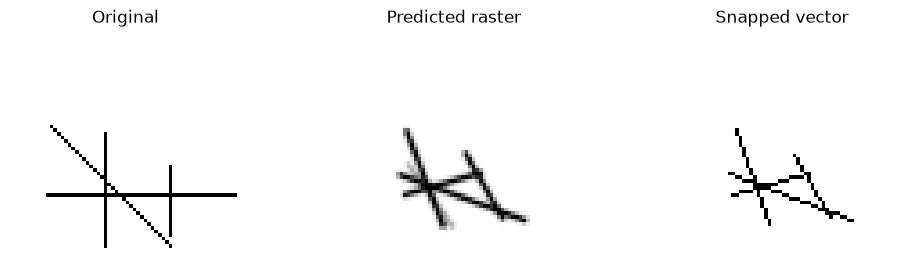

Example 8
True lines:
  (9, 0) to (20, 63), angle≈80°, confidence=1.00
  (17, 2) to (17, 59), angle≈90°, confidence=1.00
  (1, 42) to (46, 42), angle≈0°, confidence=1.00
  (7, 33) to (50, 33), angle≈0°, confidence=1.00
Predicted snapped lines:
  (15, 17) to (13, 53), angle=94°, confidence=1.00
  (20, 19) to (21, 51), angle=88°, confidence=1.00
  (25, 22) to (26, 45), angle=88°, confidence=1.00
  (11, 43) to (41, 44), angle=2°, confidence=1.00
  (37, 25) to (9, 46), angle=143°, confidence=1.00


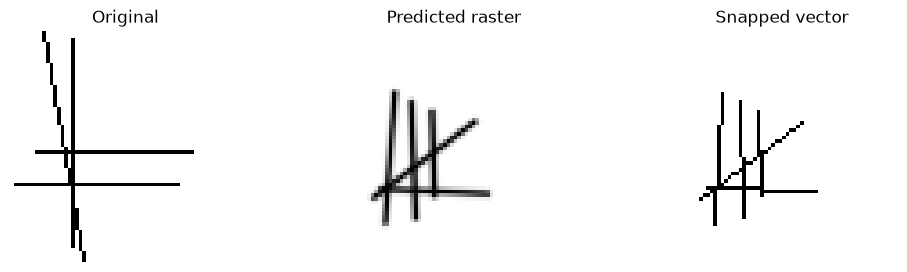

Example 9
True lines:
  (22, 34) to (8, 62), angle≈117°, confidence=1.00
  (14, 45) to (33, 45), angle≈0°, confidence=1.00
  (51, 25) to (6, 51), angle≈150°, confidence=1.00
  (42, 9) to (42, 52), angle≈90°, confidence=1.00
Predicted snapped lines:
  (26, 21) to (17, 55), angle=105°, confidence=1.00
  (44, 22) to (30, 46), angle=120°, confidence=1.00
  (37, 35) to (13, 49), angle=151°, confidence=1.00
  (44, 21) to (12, 56), angle=133°, confidence=1.00


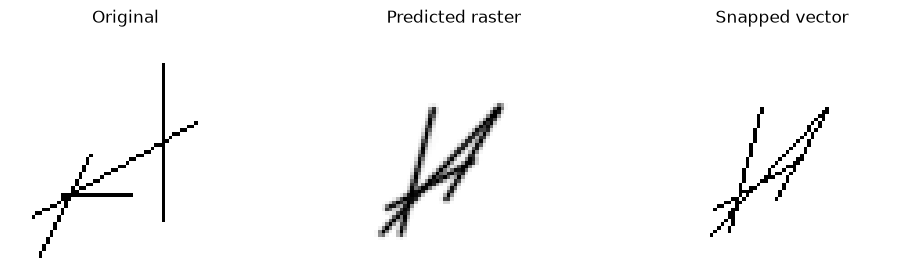

In [28]:
for sample_index in range(10):
    sample = X_test[sample_index:sample_index + 1]
    true_vector = y_test[sample_index]

    predicted_vector = vector_model.predict(sample, verbose=0)[0]
    predicted_outputs = training_model.predict(sample, verbose=0)
    predicted_raster = predicted_outputs[0][0]

    true_lines = decode_endpoint_vector(
        true_vector,
        img_size=IMG_SIZE,
        confidence_threshold=CONFIDENCE_THRESHOLD,
        snap=False
    )

    snapped_lines = decode_endpoint_vector(
        predicted_vector,
        img_size=IMG_SIZE,
        confidence_threshold=CONFIDENCE_THRESHOLD,
        snap=True
    )

    snapped_raster = rasterise_decoded_lines(snapped_lines, img_size=IMG_SIZE)

    print("Example", sample_index)

    print("True lines:")
    for line in true_lines:
        print(
            f"  ({line['x1']}, {line['y1']}) to ({line['x2']}, {line['y2']}), "
            f"angle≈{line['angle']}°, confidence={line['confidence']:.2f}"
        )

    print("Predicted snapped lines:")
    for line in snapped_lines:
        print(
            f"  ({line['x1']}, {line['y1']}) to ({line['x2']}, {line['y2']}), "
            f"angle={line['angle']}°, confidence={line['confidence']:.2f}"
        )

    plt.figure(figsize=(12, 3))

    plt.subplot(1, 3, 1)
    plt.imshow(sample.squeeze(), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(predicted_raster.squeeze(), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    plt.title("Predicted raster")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(snapped_raster.squeeze(), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    plt.title("Snapped vector")
    plt.axis("off")

    plt.show()
